# BERT tutorial: Classify spam vs no spam emails

- Using BERT and Tensorflow 2.0, we will write simple code to classify emails as spam or not spam. BERT will be used to generate sentence encoding for all emails and after that we will use a simple neural network with one drop out layer and one output layer. 

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text

#### Import the dataset (Dataset is taken from kaggle)

In [2]:
import pandas as pd

df = pd.read_csv("spam.csv")
df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.value_counts('Category')

Category
ham     4684
spam     720
dtype: int64

In [4]:
720/4684

0.1537147736976943

> % Distribution is  15%, 15% har Spam email and 85% are Ham email

In [5]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4684   4387                             Sorry, I'll call later   
spam         720    635  Please call our customer service representativ...   

               
         freq  
Category       
ham        29  
spam        4

> This data is imbalanced data, so we are applying undersampling or downsampling below and taking random 720 records from ham email
### Imbalanced data anding
##### 15% spam emails, 85% ham emails: This indicates class imbalance

- Different approach like, oversampling, SMOTE etc

In [6]:
df_spam = df[df['Category']=='spam']
df_spam.shape

(720, 2)

In [7]:
df_ham = df[df['Category']=='ham']
df_ham.shape

(4684, 2)

In [8]:
df_ham.sample(2)
# This returns only 2 samples

,Category,Message
3073,ham,Good Morning my Dear........... Have a great &...
2556,ham,Nope... C ?_ then...


In [9]:
df_ham_downsampled = df_ham.sample(df_spam.shape[0])
df_ham_downsampled.shape

(720, 2)

In [10]:
df_balanced = pd.concat([df_ham_downsampled, df_spam])
df_balanced.shape

(1440, 2)

In [11]:
df_balanced['Category'].value_counts()

ham     720
spam    720
Name: Category, dtype: int64

In [12]:
# Converting word to digit
df_balanced['spam']=df_balanced['Category'].apply(lambda x: 1 if x=='spam' else 0)
df_balanced.sample(5)

,Category,Message,spam
881,spam,18 days to Euro2004 kickoff! U will be kept in...,1
3465,ham,Its a big difference. &lt;#&gt; versus &lt;...,0
4821,spam,Phony ?350 award - Todays Voda numbers ending ...,1
2067,ham,\Si.como no?!listened2the plaid album-quite gd...,0
3140,ham,Okie ?_ wan meet at bishan? Cos me at bishan n...,0


In [13]:
df['spam']=df['Category'].apply(lambda x: 1 if x=='spam' else 0)
df.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Split it into training and test data set 

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['Message'],df['spam'], stratify=df['spam'])

In [15]:
X_train.head(4)

4549    My uncles in Atlanta. Wish you guys a great se...
1962            Later i guess. I needa do mcat study too.
3821    (Bank of Granite issues Strong-Buy) EXPLOSIVE ...
2889    You are now unsubscribed all services. Get ton...
Name: Message, dtype: object

#### Now lets import BERT model and get embeding vectors for few sample statements

In [16]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3") # This is preprocessing 1st layer
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4") # This is encoder 2nd layer

In [17]:
def get_sentence_embeding(sentences):
    preprocessed_text = bert_preprocess(sentences)
    return bert_encoder(preprocessed_text)['pooled_output']

get_sentence_embeding([
    "500$ discount. hurry up", 
    "Bhavin, are you up for a volleybal game tomorrow?"]
)

<tf.Tensor: shape=(2, 768), dtype=float32, numpy=
array([[-0.84351707, -0.5132728 , -0.8884573 , ..., -0.7474888 ,
        -0.7531474 ,  0.91964495],
       [-0.87208354, -0.50543964, -0.9444667 , ..., -0.858475  ,
        -0.7174534 ,  0.88082975]], dtype=float32)>

In [18]:
e = get_sentence_embeding([
    "banana", 
    "grapes",
    "mango",
    "jeff bezos",
    "elon musk",
    "bill gates"
]
)

In [19]:
e

<tf.Tensor: shape=(6, 768), dtype=float32, numpy=
array([[-0.7606916 , -0.14219356,  0.49604708, ...,  0.42165396,
        -0.5322139 ,  0.80312157],
       [-0.86023223, -0.21242955,  0.4915689 , ...,  0.39797997,
        -0.60506296,  0.84471667],
       [-0.71288604, -0.15463917,  0.38401607, ...,  0.352787  ,
        -0.5099134 ,  0.73474085],
       [-0.82533467, -0.35550576, -0.59069717, ..., -0.0161373 ,
        -0.61417574,  0.8723029 ],
       [-0.7504134 , -0.26812634, -0.2668972 , ...,  0.02839341,
        -0.5938099 ,  0.7974987 ],
       [-0.78544426, -0.29949743,  0.41027203, ...,  0.52225304,
        -0.4957359 ,  0.81507564]], dtype=float32)>

####  cosine_similarity: If 2 vectors are similar, then this value close to 1

In [20]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity([e[0]],[e[1]])

array([[0.99110866]], dtype=float32)

> Values near to 1 means they are similar. 0 means they are very different. Above you can use comparing "banana" vs "grapes" you get 0.99 similarity as they both are fruits

In [21]:
cosine_similarity([e[0]],[e[3]])

array([[0.84703803]], dtype=float32)

In [22]:
cosine_similarity([e[3]],[e[4]])

array([[0.9872036]], dtype=float32)

> Jeff bezos and Elon musk are more similar then Jeff bezos and banana as indicated above

## Build Model

- There are two types of models you can build in tensorflow.

       - (1) Sequential (2) Functional  (It allows multiple input and multiple o/p)

- So far we have built sequential model. But below we will build functional model. More information on these two is here: https://becominghuman.ai/sequential-vs-functional-model-in-keras-20684f766057

In [23]:
# Bert layers
# Here we are building Functional model not Sequential, here name='text' is name of that layer
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')  # this is Tensorflow " tf.keras.layers" 1st layer

# bert preprocess layer - bert 1st layer
preprocessed_text = bert_preprocess(text_input)
# bert encode layer - bert 2nd layer
outputs = bert_encoder(preprocessed_text)

# Neural network layers 
# This is  Tensorflow " tf.keras.layers"  2nd layer --> This is dropout layer, For this layer bert encoded layer's pooled_output  becomes input
# outputs['pooled_output'] will have vector of 768 for each sentence
l = tf.keras.layers.Dropout(0.1, name="dropout")(outputs['pooled_output'])

# This is  Tensorflow " tf.keras.layers"  3rd layer which does sigmoid operation and having only 1 neuron --> (l) is the input fr this layer
l = tf.keras.layers.Dense(1, activation='sigmoid', name="output")(l)

# Use inputs and outputs to construct a final model --> Here final models i/p and output parameter needs to defined
# Here we can efine multiple i/p and multiple o/p
model = tf.keras.Model(inputs=[text_input], outputs = [l])

> https://stackoverflow.com/questions/47605558/importerror-failed-to-import-pydot-you-must-install-pydot-and-graphviz-for-py

In [24]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
text (InputLayer)               [(None,)]            0                                            
__________________________________________________________________________________________________
keras_layer (KerasLayer)        {'input_word_ids': ( 0           text[0][0]                       
__________________________________________________________________________________________________
keras_layer_1 (KerasLayer)      {'sequence_output':  109482241   keras_layer[0][0]                
                                                                 keras_layer[0][1]                
                                                                 keras_layer[0][2]                
______________________________________________________________________________________________

In [25]:
len(X_train)

4053

In [26]:
#Model matrics
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=METRICS)

### Train the model

In [27]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
127/127 [==============================] - 828s 6s/step - loss: 0.3572 - accuracy: 0.8584 - precision: 0.1964 - recall: 0.0204
Epoch 2/5
127/127 [==============================] - 809s 6s/step - loss: 0.2550 - accuracy: 0.8858 - precision: 0.7730 - recall: 0.2019
Epoch 3/5
127/127 [==============================] - 3682s 29s/step - loss: 0.2173 - accuracy: 0.9067 - precision: 0.8045 - recall: 0.3963
Epoch 4/5
127/127 [==============================] - 850s 7s/step - loss: 0.1911 - accuracy: 0.9213 - precision: 0.8464 - recall: 0.5000
Epoch 5/5
127/127 [==============================] - 909s 7s/step - loss: 0.1769 - accuracy: 0.9317 - precision: 0.8603 - recall: 0.5815


In [28]:
model.evaluate(X_test, y_test)

43/43 [==============================] - 265s 6s/step - loss: 0.1419 - accuracy: 0.9563 - precision: 0.9172 - recall: 0.7389


[0.14190156757831573,
 0.9563286304473877,
 0.9172413945198059,
 0.7388888597488403]

In [29]:
y_predicted = model.predict(X_test)
y_predicted = y_predicted.flatten()

In [30]:
import numpy as np

y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted

array([0, 0, 0, ..., 0, 0, 0])

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_predicted)
cm

array([[1159,   12],
       [  47,  133]], dtype=int64)

Text(33.0, 0.5, 'Truth')

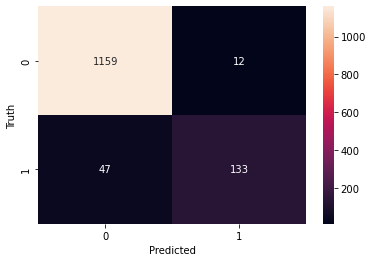

In [32]:
from matplotlib import pyplot as plt
import seaborn as sn
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [33]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1171
           1       0.92      0.74      0.82       180

    accuracy                           0.96      1351
   macro avg       0.94      0.86      0.90      1351
weighted avg       0.96      0.96      0.95      1351



### Inference

In [34]:
reviews = [
    'Reply to win Â£100 weekly! Where will the 2006 FIFA World Cup be held? Send STOP to 87239 to end service',
    'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days. T Cs Box177. M221BP. 2yr warranty. 150ppm. 16 . p pÂ£3.99',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricket game tomorrow',
    "Why don't you wait 'til at least wednesday to see if you get your ."
]
model.predict(reviews)

array([[0.51893723],
       [0.59198797],
       [0.44530278],
       [0.05138701],
       [0.01821163]], dtype=float32)

> Here 1st,2nd and 3rd are spam email, so value came near to 1 and remaining are near to 0